In [234]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import packages for modelling
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [183]:
df=pd.read_csv('waze_dataset.csv')
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [188]:
#remove the useless variable
df=df.drop(columns=['ID'])

In [190]:
# remove the missing observations in target varivable
df=df.dropna(subset=['label'])

In [192]:
# check the balance of the target variable
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

In [194]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530
std,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [196]:
# transfer the target variable into a binary variable
df['label_encoded']=df['label'].map({'retained':0,'churned':1})

In [198]:
df['label_encoded'].value_counts(normalize=True)

label_encoded
0    0.822645
1    0.177355
Name: proportion, dtype: float64

In [200]:
df['device_encoded']=df['device'].map({'iPhone':1,'Android':0})

In [202]:
df['device_encoded'].value_counts()

device_encoded
1    9225
0    5074
Name: count, dtype: int64

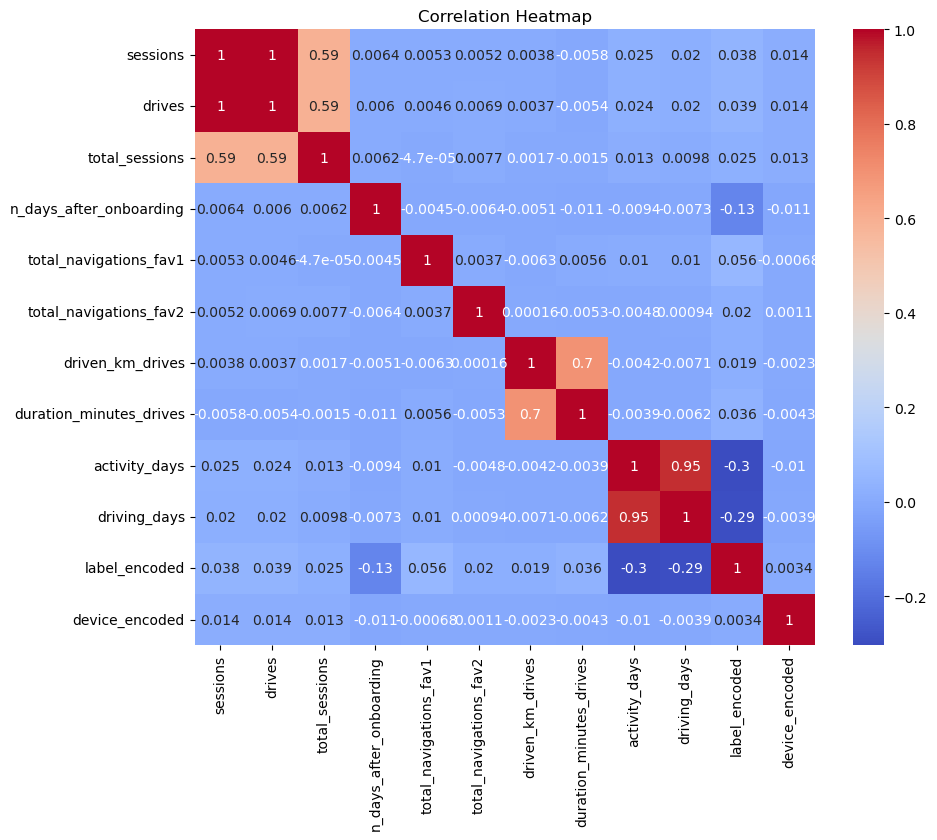

In [204]:
#plot the heatmap to check the correlation between numerical variables , to avoid the multicollinearity when modeling 
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [205]:
# feature engineering 
df['drives_per_day']=df['drives']/df['activity_days'].replace(0,1)

In [206]:
df["km_per_drive"] = df["driven_km_drives"] / df["drives"].replace(0,1)

In [207]:
df["session_per_day"] = df["sessions"] / df["activity_days"].replace(0,1)

In [212]:
df["drive_ratio"] = df["driving_days"] / df["activity_days"].replace(0,1)

In [214]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,label_encoded,device_encoded,drives_per_day,km_per_drive,session_per_day,drive_ratio
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530,0.177355,0.645150,9.589256,264.977250,11.483702,0.735071
std,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835,0.381982,0.478485,20.899841,756.534125,25.345625,0.273400
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000,0.000000,0.000000,1.008775,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,0.000000,0.000000,1.400000,33.253894,1.620690,0.631579
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,0.000000,1.000000,3.500000,74.905935,4.166667,0.800000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,0.000000,1.000000,8.416667,185.466720,10.000000,0.960000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000,1.000000,1.000000,385.000000,16480.939080,479.000000,1.000000


In [216]:
# select continuous numerical columns to scale
cols_to_scale = ['sessions', 'total_sessions', 
                 'n_days_after_onboarding', 'total_navigations_fav1', 
                 'total_navigations_fav2', 'driven_km_drives', 
                 'duration_minutes_drives', 'activity_days',
                 'drives_per_day', 'km_per_drive', 'session_per_day', 'drive_ratio']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [218]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,label_encoded,device_encoded,drives_per_day,km_per_drive,session_per_day,drive_ratio
count,1.429900e+04,14299.000000,1.429900e+04,1.429900e+04,1.429900e+04,1.429900e+04,1.429900e+04,1.429900e+04,1.429900e+04,14299.000000,14299.000000,14299.000000,1.429900e+04,1.429900e+04,1.429900e+04,1.429900e+04
mean,6.758082e-17,67.255822,-1.371493e-16,-7.031387e-17,5.838784e-18,-2.832431e-17,-1.142911e-17,-4.074726e-17,6.459931e-18,12.182530,0.177355,0.645150,-5.963013e-18,4.422568e-17,-3.379041e-17,-3.061014e-16
std,1.000035e+00,65.947295,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,7.833835,0.381982,0.478485,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00
min,-9.986392e-01,0.000000,-1.390221e+00,-1.732870e+00,-8.242423e-01,-6.535557e-01,-1.590473e+00,-1.274845e+00,-1.724162e+00,0.000000,0.000000,0.000000,-4.588356e-01,-3.489303e-01,-4.531000e-01,-2.688727e+00
25%,-7.137519e-01,20.000000,-7.276108e-01,-8.658515e-01,-7.565413e-01,-6.535557e-01,-7.294058e-01,-7.072173e-01,-8.368282e-01,5.000000,0.000000,0.000000,-3.918471e-01,-3.063067e-01,-3.891542e-01,-3.785512e-01
50%,-3.050006e-01,48.000000,-2.263747e-01,-2.798359e-03,-3.435650e-01,-4.550962e-01,-2.187145e-01,-2.657580e-01,5.050554e-02,12.000000,0.000000,1.000000,-2.913644e-01,-2.512484e-01,-2.887004e-01,2.374957e-01
75%,3.762517e-01,93.000000,4.698979e-01,8.681863e-01,3.808359e-01,2.946397e-01,5.012477e-01,4.162625e-01,8.269226e-01,19.000000,0.000000,1.000000,-5.610715e-02,-1.051021e-01,-5.854083e-02,8.227402e-01
max,8.204459e+00,596.000000,7.538328e+00,1.733222e+00,7.543604e+00,8.497632e+00,6.842216e+00,9.660199e+00,1.714256e+00,30.000000,1.000000,1.000000,1.796300e+01,2.143529e+01,1.844629e+01,9.690514e-01


In [220]:
# define X and y
X = df.drop(columns=['label', 'label_encoded', 'device', 'drives', 'driving_days'])
y = df['label_encoded']

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(11439, 13)
(2860, 13)


In [222]:
# fit logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [224]:
y_pred = model.predict(X_test)

In [226]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      2337
           1       0.60      0.10      0.17       523

    accuracy                           0.82      2860
   macro avg       0.72      0.54      0.54      2860
weighted avg       0.79      0.82      0.77      2860



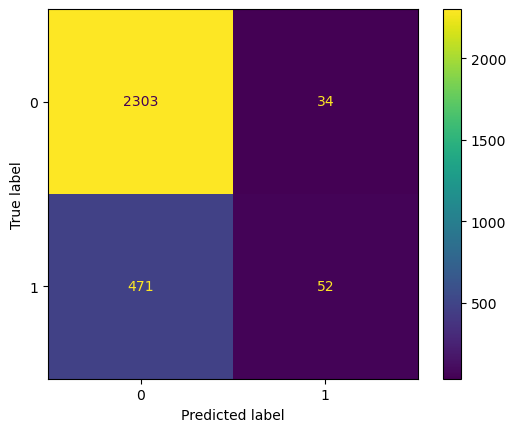

In [236]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

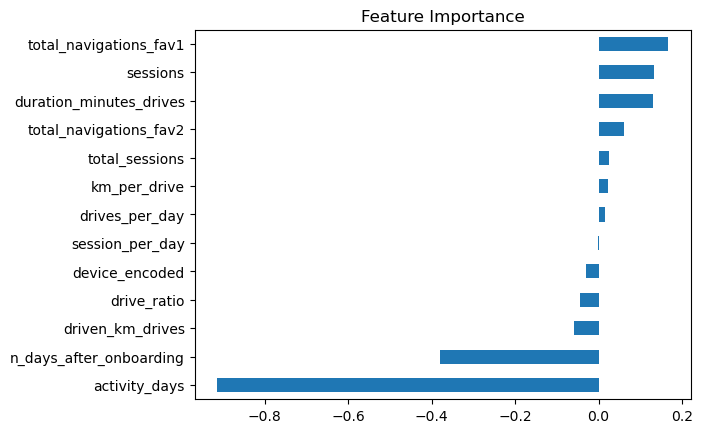

In [238]:
# get feature importance
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()